# Synthetic Dataset


Import libraries


In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from custom_lstm.utils import ew_acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc

In [2]:
OUTPUT_FILE = "../../data/preprocessed/synthetic_dataset.csv"

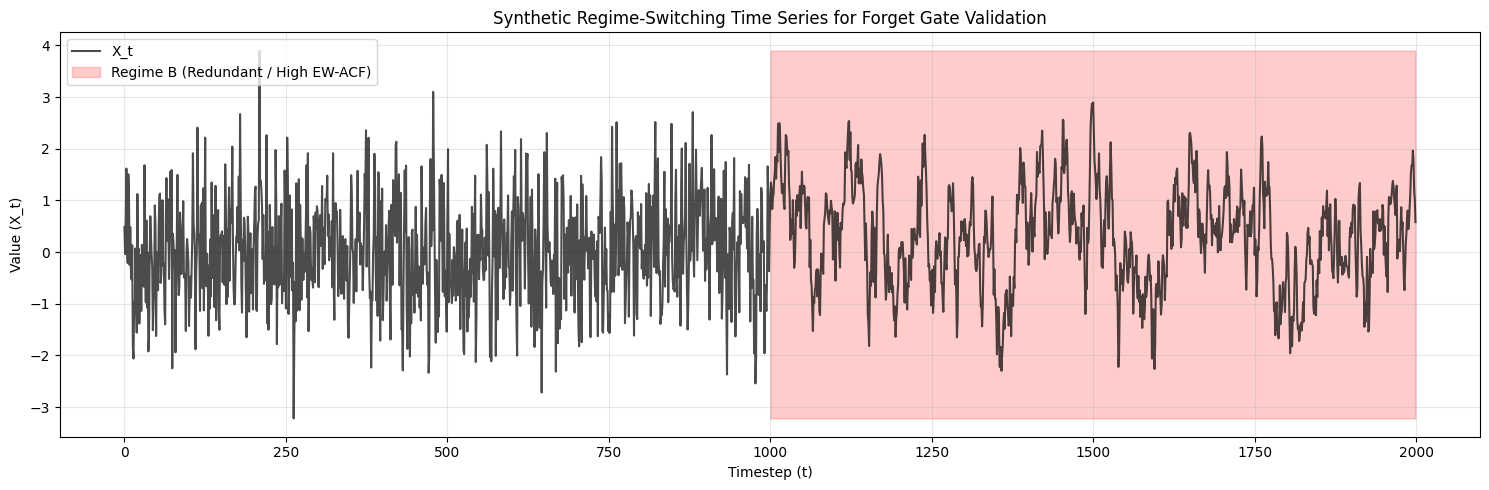

In [36]:
def generate_regime_switching_series(
    total_steps: int = 10000,
    regime_duration: int = 1000,
    ar_coeff_redundant: float = 0.9,
    ar_coeff_noise: float = 0.4,
    noise_std: float = 1.0,
    seed: int = 42,
    target_std: float = 1.0,
) -> pd.DataFrame:
    """
    Generates a continuous time series alternating between high autocorrelation
    and pure white noise to test structural memory gating.

    Parameters:
    -----------
    total_steps : int
        Total length of the generated time series.
    regime_duration : int
        The number of timesteps before switching to the alternate regime.
    ar_coeff_redundant : float
        The AR(1) coefficient for Regime B (Highly redundant). Should be close to 1.
    ar_coeff_noise : float
        The AR(1) coefficient for Regime A (White noise). Must be 0.
    noise_std : float
        Standard deviation of the Gaussian noise term (\epsilon).
    seed : int
        Random seed for reproducibility.

    Returns:
    --------
    pd.DataFrame containing:
        - 'value': The generated time series sequence X_t
        - 'is_redundant': Boolean mask (1 if in Regime B, 0 if in Regime A)
    """
    np.random.seed(seed)

    # Initialize arrays
    X = np.zeros(total_steps)
    is_redundant = np.zeros(total_steps, dtype=int)

    # Determine the phi coefficient for each timestep beforehand
    # Creates a square wave of 0s and 1s, multiplied by the AR coefficients
    regime_wave = (np.arange(total_steps) // regime_duration) % 2
    phi_t = np.where(regime_wave == 1, ar_coeff_redundant, ar_coeff_noise)
    is_redundant = regime_wave  # Ground truth mask

    scale_factor = np.sqrt(1 - phi_t**2)

    # Generate the scaled noise for each timestep
    epsilon = np.random.normal(0, target_std, total_steps) * scale_factor

    # Generate the continuous sequence
    X[0] = epsilon[0]
    for t in range(1, total_steps):
        X[t] = (phi_t[t] * X[t - 1]) + epsilon[t]

    # Compile into a DataFrame for easy export and alignment
    df = pd.DataFrame({"value": X, "is_redundant": is_redundant})

    return df


# ==========================================
# Execution & Verification
# ==========================================
if __name__ == "__main__":
    # Generate a standard test set
    synthetic_data = generate_regime_switching_series(total_steps=2000, regime_duration=1000, ar_coeff_redundant=0.9, ar_coeff_noise=0.2)

    # Visual verification of the structural shift
    plt.figure(figsize=(15, 5))
    plt.plot(synthetic_data["value"], label="X_t", color="black", alpha=0.7)

    # Highlight the redundant regimes
    plt.fill_between(
        synthetic_data.index,
        synthetic_data["value"].min(),
        synthetic_data["value"].max(),
        where=(synthetic_data["is_redundant"] == 1),
        color="red",
        alpha=0.2,
        label="Regime B (Redundant / High EW-ACF)",
    )
    plt.title("Synthetic Regime-Switching Time Series for Forget Gate Validation")
    plt.xlabel("Timestep (t)")
    plt.ylabel("Value (X_t)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [37]:
time_series = synthetic_data['value']
time_series.to_csv(OUTPUT_FILE, index=False)

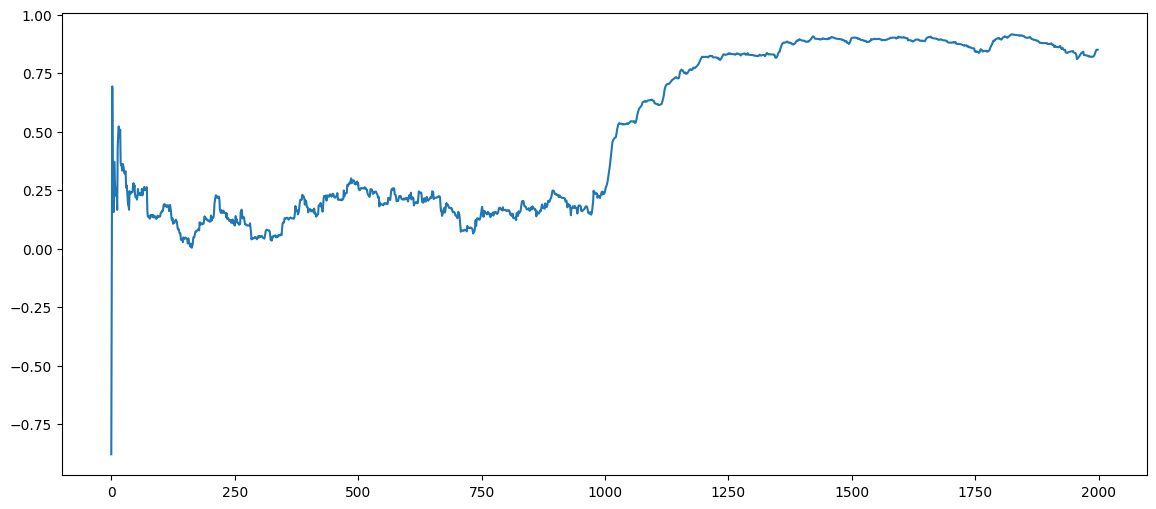

In [38]:
autocorr = ew_acf(time_series, lag=1, lambda_=0.99)
plt.figure(figsize=(14, 6))
plt.plot(autocorr)

### ACF

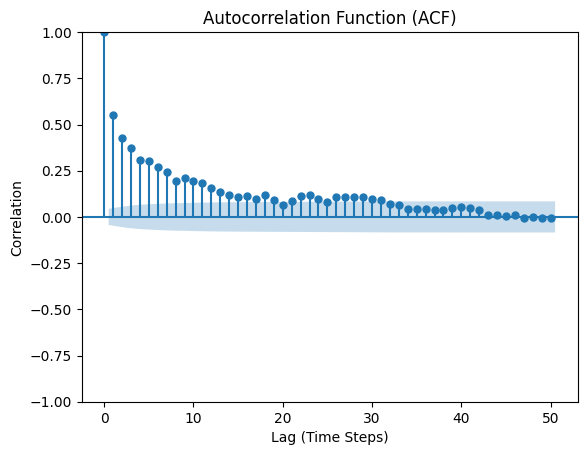

In [39]:
plot_acf(time_series, lags=50, alpha=0.05)
plt.title("Autocorrelation Function (ACF)")
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation")
plt.show()

### PACF

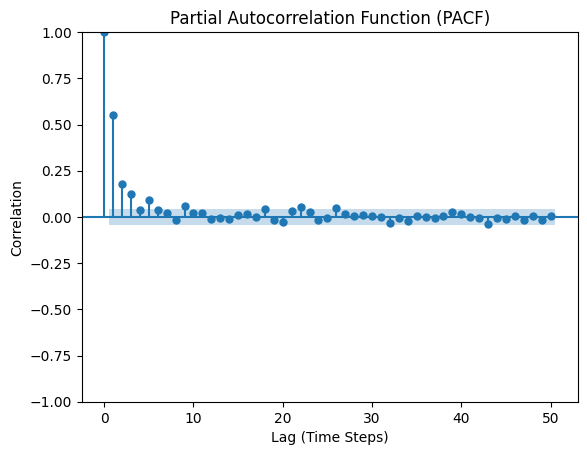

In [40]:
plot_pacf(time_series, lags=50)
plt.title("Partial Autocorrelation Function (PACF)")
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation")
plt.show()

## Hurst Exponent


Hurst Exponent (H): 0.5475


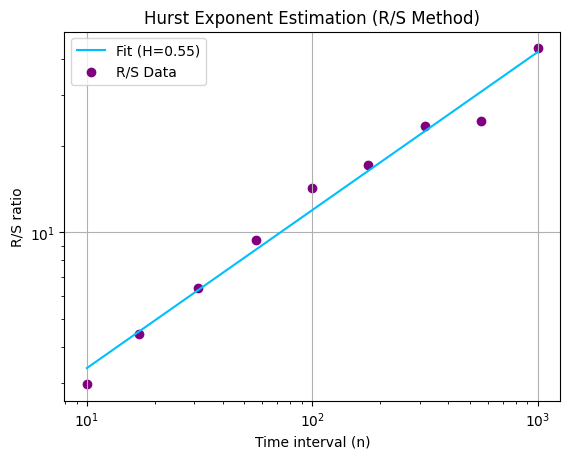

In [11]:
H, c, data = compute_Hc(time_series[2000:3000], kind="change", simplified=False)

print(f"Hurst Exponent (H): {H:.4f}")
f, ax = plt.subplots()
ax.plot(data[0], c * data[0] ** H, color="deepskyblue", label=f"Fit (H={H:.2f})")
ax.scatter(data[0], data[1], color="purple", label="R/S Data")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Time interval (n)")
ax.set_ylabel("R/S ratio")
ax.legend()
plt.title("Hurst Exponent Estimation (R/S Method)")
plt.grid(True)
plt.show()